In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import time

In [2]:
ctype = np.float64

### `init_grid` 
input: `shape`: (shape of a grid) ; `threshold`: density of the living cells 
output: `grid` 2darray of boolean 
initialize a random grid (2darray) of double float of dimension shape (the threshold help to define density)

In [3]:
def init_grid(shape, threshold=0.50):
    """
    initialize a random  grid of double float 
    of dimension shape (the threshold help to define density)
    """
    x = np.zeros(shape,dtype=ctype)
    r = np.random.random(shape)
    x[:,:] = (r> 1.0 - threshold)
    return x

In [4]:
def get_nbneigh(grid, coord):
    irange, jrange = grid.shape
    i, j = coord
    biinf = max(0, i - 1)
    bisup = min(irange - 1, i + 1)
    bjinf = max(0,j - 1)
    bjsup = min(jrange - 1,j + 1)
    nb_neigh = 0
    # loop over neighs to count living cells
    for ii in range(biinf, bisup + 1):
        for jj in range(bjinf, bjsup + 1):
            if grid[ii, jj]:
                nb_neigh = nb_neigh + 1
    # in my count I count current cell itself substract the value
    nb_neigh = nb_neigh-grid[i, j]
    return nb_neigh

### `life_step(grid)` : 
- input: `grid` a 2darray of cells (boolean); 
- output: `res_grid`  2darray ; the state of each cell of `grid` resulting from the application of the rules

In [5]:
def life_step(grid):
    irange, jrange = grid.shape
    res_grid = np.zeros(grid.shape,dtype=ctype)
    for j in range(jrange):
        for i in range(irange):
            # by default cell_state is dead
            cell_state = False
            # loop over neighs to count living cells
            nb_neigh = get_nbneigh(grid,(i,j))
            # if 2 neighbors cell state isn't modified
            if nb_neigh == 2:
                cell_state = grid[i, j]
            # if 3 neighbors cell state is alive
            elif nb_neigh == 3:
                cell_state = 1
            # in other case cell state is dead (default state)
            res_grid[i, j] = cell_state
    return res_grid

### `conway(grid,n)`
From an initial grid, run n iterations of evolution and display the intermediate statistics (number of alive cells)

In [6]:
def conway(grid, n):
    """
    From an initial grid, run n iterations of evolution and display 
    the intermediate statistics (number of alive cells)
    """
    for i in range(n):
        alive = np.sum(grid)
        print(f'alive cells: {alive:.0f}: {alive / grid.size * 100:2.2f}%')
        grid = life_step(grid)
    return grid

### Exemple on a little grid

In [7]:
grid = init_grid((10,10), 0.5)

In [8]:
grid

array([[1., 1., 1., 0., 0., 1., 1., 0., 1., 0.],
       [1., 1., 1., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0., 1., 1., 1., 0., 1.],
       [0., 1., 1., 0., 0., 0., 0., 1., 0., 1.],
       [1., 0., 1., 1., 1., 0., 0., 0., 0., 1.],
       [0., 1., 0., 1., 0., 1., 1., 0., 1., 0.],
       [1., 0., 0., 0., 1., 1., 0., 1., 0., 0.],
       [1., 1., 1., 0., 1., 1., 0., 0., 1., 1.],
       [0., 1., 1., 0., 0., 0., 0., 1., 1., 1.],
       [1., 1., 0., 0., 1., 1., 0., 1., 1., 1.]])

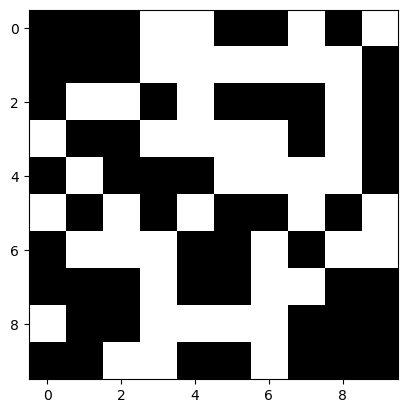

In [10]:
plt.imshow(grid,cmap=plt.cm.binary)

In [11]:
grid = life_step(grid)

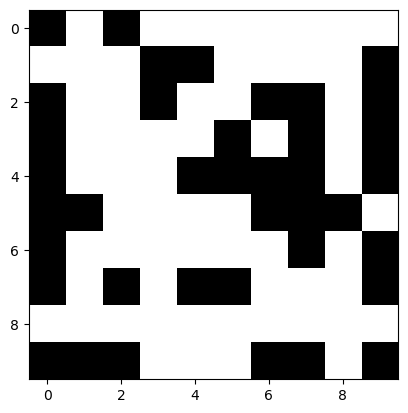

In [12]:
plt.imshow(grid,cmap=plt.cm.binary)

In [13]:
conway(grid,5)

alive cells: 39: 39.00%
alive cells: 33: 33.00%
alive cells: 37: 37.00%
alive cells: 30: 30.00%
alive cells: 34: 34.00%


array([[0., 0., 0., 0., 1., 0., 0., 0., 1., 0.],
       [0., 1., 0., 1., 1., 0., 0., 0., 0., 1.],
       [1., 0., 1., 0., 0., 1., 1., 0., 0., 1.],
       [1., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 0., 0., 0., 0., 0., 0., 1., 1.],
       [0., 1., 1., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 1., 0., 0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

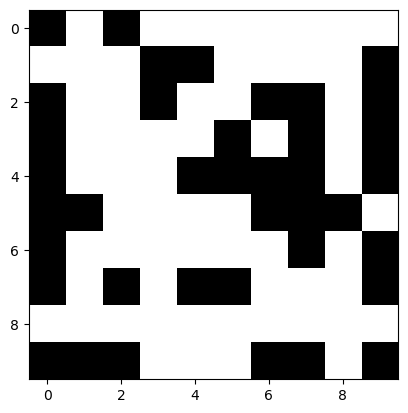

In [14]:
plt.imshow(grid,cmap=plt.cm.binary)

## Question 1.a 
Utilisez le notebook avec différentes tailles progressivement croissantes ((10,10) (100,100), (1000, 1000), (2000, 2000), …) et estimer les temps d’exécution de `conway` avec la commande magique `%time`

In [7]:
values_n = [10, 50, 100, 250, 500, 750, 1000, 1250, 1500, 1750, 2000]
times = []
n_cells = []


for n in values_n:

    grid = init_grid((n,n), 0.5)

    print("----- n = ",n," -----")  
    tic = time.time()
    %time conway(grid,5)
    toc = time.time()
    elapsed_time = toc - tic
    times.append(elapsed_time)
    
    n_cells.append(n*n)

----- n =  10  -----
alive cells: 48: 48.00%
alive cells: 35: 35.00%
alive cells: 20: 20.00%
alive cells: 13: 13.00%
alive cells: 12: 12.00%
CPU times: total: 0 ns
Wall time: 2.99 ms
----- n =  50  -----
alive cells: 1228: 49.12%
alive cells: 748: 29.92%
alive cells: 686: 27.44%
alive cells: 640: 25.60%
alive cells: 607: 24.28%
CPU times: total: 62.5 ms
Wall time: 80 ms
----- n =  100  -----
alive cells: 4976: 49.76%
alive cells: 2750: 27.50%
alive cells: 2577: 25.77%
alive cells: 2550: 25.50%
alive cells: 2385: 23.85%
CPU times: total: 156 ms
Wall time: 322 ms
----- n =  250  -----
alive cells: 31198: 49.92%
alive cells: 17405: 27.85%
alive cells: 16153: 25.84%
alive cells: 15730: 25.17%
alive cells: 14984: 23.97%
CPU times: total: 1.25 s
Wall time: 1.96 s
----- n =  500  -----
alive cells: 125039: 50.02%
alive cells: 68774: 27.51%
alive cells: 63607: 25.44%
alive cells: 62689: 25.08%
alive cells: 59865: 23.95%
CPU times: total: 6.3 s
Wall time: 7.74 s
----- n =  750  -----
alive cell

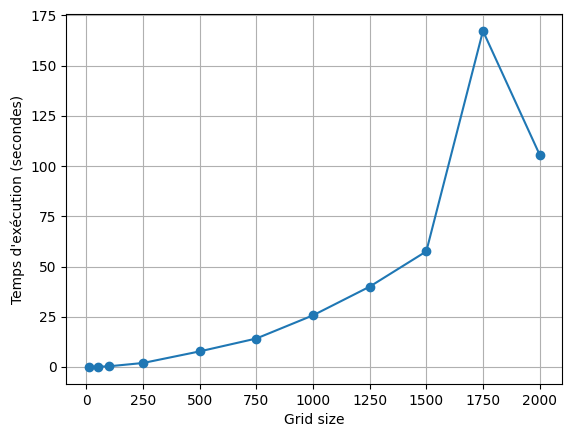

In [8]:
plt.plot(values_n, times, marker='o')
plt.xlabel('Grid size')
plt.ylabel("Temps d'exécution (secondes)")
plt.grid(True)
plt.show()

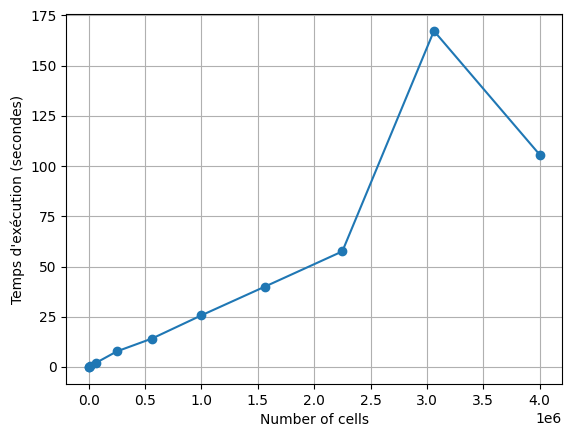

In [9]:
plt.plot(n_cells, times, marker='o')
plt.xlabel('Number of cells')
plt.ylabel("Temps d'exécution (secondes)")
plt.grid(True)
plt.show()

# Questions 2 cProfile

In [8]:
import cProfile

## Question 2.a 
Utilisez `cProfile` afin de réaliser un profilage du code (sur des grilles ayant un temps de restitution de quelques secondes ~1000x1000). Que remarquez-vous sur les fonctions les plus coûteuses ?

In [9]:
grid = init_grid((1000,1000), 0.5)

cProfile.run('conway(grid,5)', sort='ncalls')

alive cells: 499431: 49.94%
alive cells: 274636: 27.46%
alive cells: 253962: 25.40%
alive cells: 249663: 24.97%
alive cells: 238376: 23.84%
         25002805 function calls (25002804 primitive calls) in 11.536 seconds

   Ordered by: call count

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
 10000043    1.046    0.000    1.046    0.000 {built-in method builtins.max}
 10000016    1.030    0.000    1.030    0.000 {built-in method builtins.min}
  5000000    7.905    0.000    9.981    0.000 3970450040.py:1(get_nbneigh)
      510    0.000    0.000    0.000    0.000 {built-in method builtins.isinstance}
      210    0.000    0.000    0.000    0.000 enum.py:1544(_get_value)
      116    0.000    0.000    0.000    0.000 {built-in method builtins.len}
      100    0.000    0.000    0.000    0.000 enum.py:1129(__new__)
      100    0.000    0.000    0.000    0.000 enum.py:726(__call__)
       75    0.000    0.000    0.000    0.000 traitlets.py:643(get)
       75    0.00

## Question 2.b 
Quel surcoût en temps d’exécution observez-vous par rapport à une exécution sans profilage ?

## Question 2.c 
Générez la sortie du profilage dans un fichier `conway_01.prof`

In [ ]:
cProfile.run('conway(grid,5)', 'conway_01.prof')

alive cells: 499689: 49.97%
alive cells: 274894: 27.49%
alive cells: 253420: 25.34%
alive cells: 250218: 25.02%
alive cells: 237749: 23.77%


# Questions 3 optimisation 1 Inlining

## Question 3.a 
Créez une fonction `life_step_in` qui est une intégration du corps de `get_nbneigh` dans `life_step` et modifiez `conway` pour utiliser `life_step_in` à la place de `life_step`.

In [10]:
def life_step_in(grid):
    irange, jrange = grid.shape
    res_grid = np.zeros(grid.shape,dtype=ctype)
    for j in range(jrange):
        for i in range(irange):
            # by default cell_state is dead
            cell_state = False
            
            
            #### GET_NBNEIGH ####

            irange, jrange = grid.shape
            biinf = max(0, i - 1)
            bisup = min(irange - 1, i + 1)
            bjinf = max(0,j - 1)
            bjsup = min(jrange - 1,j + 1)
            nb_neigh = 0
            # loop over neighs to count living cells
            for ii in range(biinf, bisup + 1):
                for jj in range(bjinf, bjsup + 1):
                    if grid[ii, jj]:
                        nb_neigh = nb_neigh + 1
            # in my count I count current cell itself substract the value
            nb_neigh = nb_neigh-grid[i, j]


            # if 2 neighbors cell state isn't modified
            if nb_neigh == 2:
                cell_state = grid[i, j]
            # if 3 neighbors cell state is alive
            elif nb_neigh == 3:
                cell_state = 1
            # in other case cell state is dead (default state)
            res_grid[i, j] = cell_state
    return res_grid

In [11]:
def conway_in(grid, n):
    """
    From an initial grid, run n iterations of evolution and display 
    the intermediate statistics (number of alive cells)
    """
    for i in range(n):
        alive = np.sum(grid)
        print(f'alive cells: {alive:.0f}: {alive / grid.size * 100:2.2f}%')
        grid = life_step_in(grid)
    return grid

## Question 3.b 
Estimez les temps d’exécution de cette nouvelle version et réalisez un profilage avec `cProfile`. Que constatez vous sur les performances ?

In [17]:
%time conway_in(grid,2)

alive cells: 1999208: 49.98%
alive cells: 1096487: 27.41%
CPU times: total: 32.5 s
Wall time: 42.7 s


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 1., 1., ..., 0., 1., 1.],
       [0., 1., 1., ..., 1., 0., 1.],
       [0., 0., 0., ..., 1., 1., 0.]], shape=(2000, 2000))

In [7]:
for n in values_n:

    grid = init_grid((n,n), 0.5)

    print("----- n = ",n," -----")  
    %time conway_in(grid,5)

NameError: name 'values_n' is not defined

In [16]:
grid = init_grid((1000,1000), 0.5)

cProfile.run('conway_in(grid,5)', sort='ncalls')

alive cells: 499442: 49.94%
alive cells: 274888: 27.49%
alive cells: 255061: 25.51%
alive cells: 251534: 25.15%
alive cells: 239573: 23.96%
         20002874 function calls (20002862 primitive calls) in 11.115 seconds

   Ordered by: call count

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
 10000043    1.090    0.000    1.090    0.000 {built-in method builtins.max}
 10000016    1.066    0.000    1.066    0.000 {built-in method builtins.min}
      517    0.000    0.000    0.000    0.000 {built-in method builtins.isinstance}
      210    0.000    0.000    0.000    0.000 enum.py:1544(_get_value)
      118    0.000    0.000    0.000    0.000 {built-in method builtins.len}
      100    0.000    0.000    0.000    0.000 enum.py:1129(__new__)
      100    0.000    0.000    0.000    0.000 enum.py:726(__call__)
       77    0.000    0.000    0.000    0.000 traitlets.py:643(get)
       77    0.000    0.000    0.000    0.000 traitlets.py:675(__get__)
       45    0.057  

# Questions 4 Profilage life_step_in

## Question 4.a 
Avec line_profiler, profilez ligne à ligne la fonction life_step_in en ne jouant qu’une seule itération. 

In [18]:
from line_profiler import LineProfiler

In [23]:
grid = init_grid((1000,1000), 0.5)

In [24]:
# Criação do profiler
lp = LineProfiler()

# Adicionamos as funções que queremos perfilar
lp.add_function(life_step_in)
lp.add_function(conway_in)

# Usamos lp para decorar a função principal
lp_wrapper = lp(conway_in)

# Chamamos a função perfilada
lp_wrapper(grid, 1)  # executa conway_in(grid, n=10)

# Mostramos o relatório de performance
lp.print_stats()

alive cells: 499535: 49.95%
Timer unit: 1e-07 s

Total time: 62.2553 s
File: C:\Users\ferna\AppData\Local\Temp\ipykernel_14716\1597321833.py
Function: conway_in at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def conway_in(grid, n):
     2                                               """
     3                                               From an initial grid, run n iterations of evolution and display 
     4                                               the intermediate statistics (number of alive cells)
     5                                               """
     6         2         57.0     28.5      0.0      for i in range(n):
     7         1      35174.0  35174.0      0.0          alive = np.sum(grid)
     8         1      27512.0  27512.0      0.0          print(f'alive cells: {alive:.0f}: {alive / grid.size * 100:2.2f}%')
     9         1  622490513.0 6.22e+08    100.0          grid = life_step_in(gri

## Question 4.b
Quel surcoût en temps d’exécution observez-vous par rapport à une exécution sans profilage ?

## Question 4.c
Quels sont les hot spots mis en évidence par le profilage ligne à ligne ?